In [1]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("alldata_new.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

import sys
import os

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

from HubbardTweezer.Hubbard.lattice import sqr_lattice

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([4, 4]))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

3001
1190


## Coordinate chart

| 1 | 2 | 3 | 4 |
|---|---|---|---|
| 5 | 6 | 7 | 8 |
| 9 | 10 | 11 | 12 |
| 13 | 14 | 15 | 16 |

## Trap depth

## Position effect

### Average U over grid

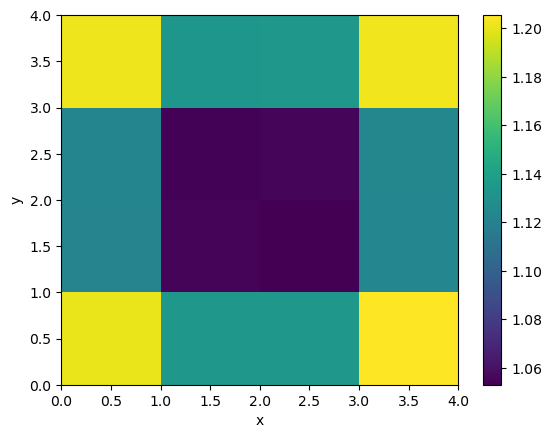

In [3]:
avgU = np.mean(dat["U_i"][mask], axis=0)
plt.pcolormesh(avgU.reshape(4, 4))
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()

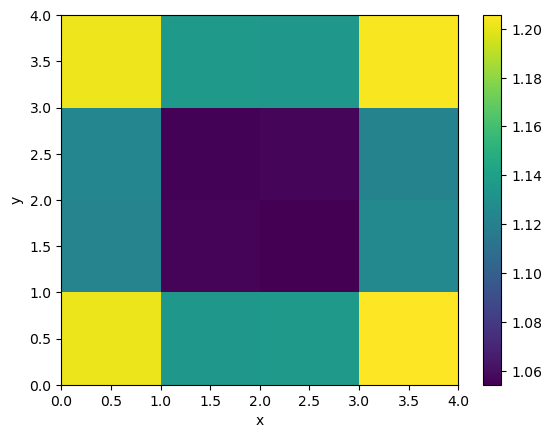

In [40]:
avgU = np.median(dat["U_i"][mask], axis=0)
plt.pcolormesh(avgU.reshape(4, 4))
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()

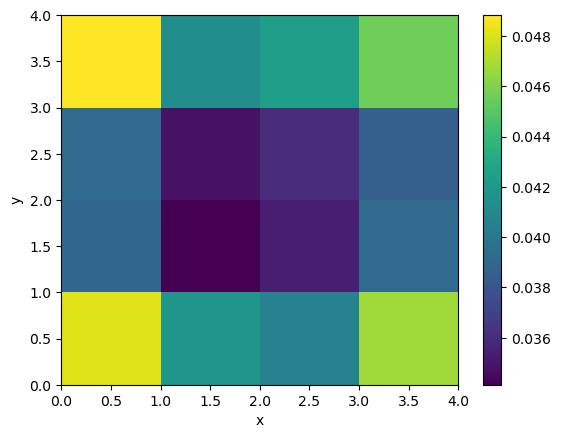

In [39]:
avgU = np.std(dat["U_i"][mask], axis=0)
plt.pcolormesh(avgU.reshape(4, 4))
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()

This clearly indicate that one descrptor is the number of neighbors.

### Site index

In [48]:
avgU = np.mean(dat["U_i"][mask], axis=0)

Text(0, 0.5, 'U_i')

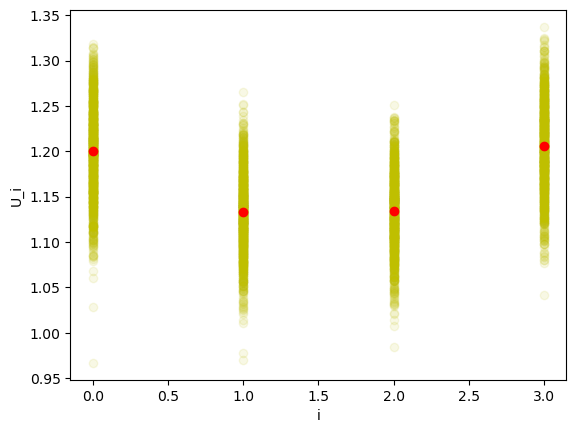

In [56]:
sidx = list(range(4))
plt.scatter(
    np.tile(sidx, nmask), dat["U_i"][mask][:, sidx].flatten(), color="y", alpha=0.1
)
plt.scatter(sidx, avgU[sidx].flatten(), color="r", alpha=1)
plt.xlabel("i")
plt.ylabel("U_i")

Text(0, 0.5, 'U_i')

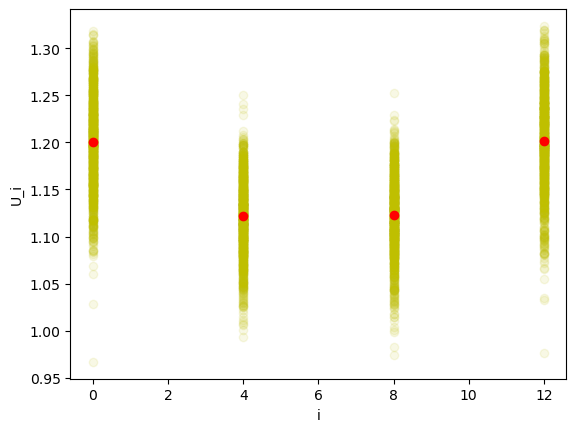

In [57]:
sidx = list(range(0, 16, 4))
plt.scatter(
    np.tile(sidx, nmask), dat["U_i"][mask][:, sidx].flatten(), color="y", alpha=0.1
)
plt.scatter(sidx, avgU[sidx].flatten(), color="r", alpha=1)
plt.xlabel("i")
plt.ylabel("U_i")

Text(0, 0.5, 'U_i')

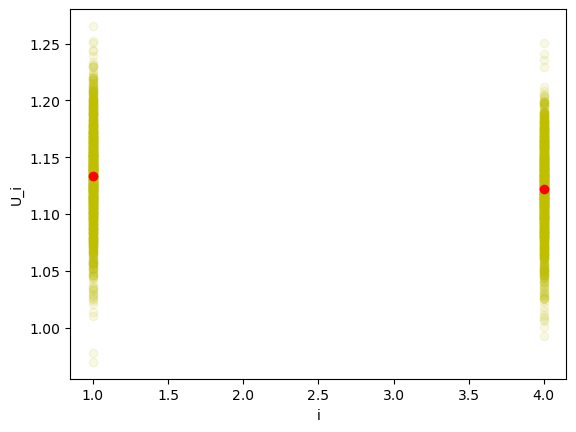

In [58]:
sidx = [1, 4]
plt.scatter(
    np.tile(sidx, nmask), dat["U_i"][mask][:, sidx].flatten(), color="y", alpha=0.1
)
plt.scatter(sidx, avgU[sidx].flatten(), color="r", alpha=1)
plt.xlabel("i")
plt.ylabel("U_i")

### Neighboring number

In [63]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


nn = nneighbor(width, height)
print(nn)

[2 3 3 2 3 4 4 3 3 4 4 3 2 3 3 2]


Text(0, 0.5, 'U_i')

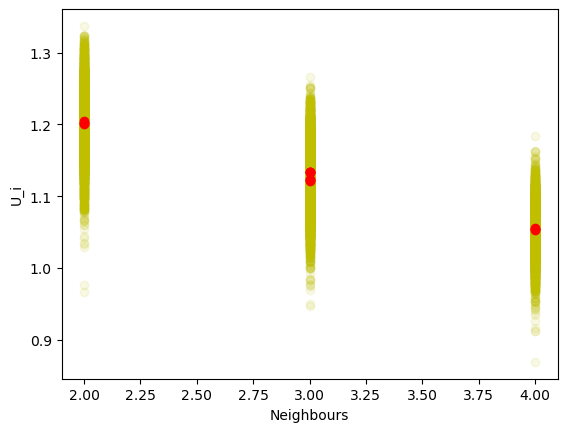

In [64]:
sidx = list(range(16))
plt.scatter(
    np.tile(nn, nmask), dat["U_i"][mask][:, sidx].flatten(), color="y", alpha=0.1
)
plt.scatter(nn, avgU[sidx].flatten(), color="r", alpha=1)
plt.xlabel("Neighbours")
plt.ylabel("U_i")

### Average trap spacing

The sum of trap spacing is a factor to count both the number of neighbors and the average trap spacing.

In [76]:
from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


avgr = avg_trap_spacing(np.arange(16))

Text(0, 0.5, 'U_i')

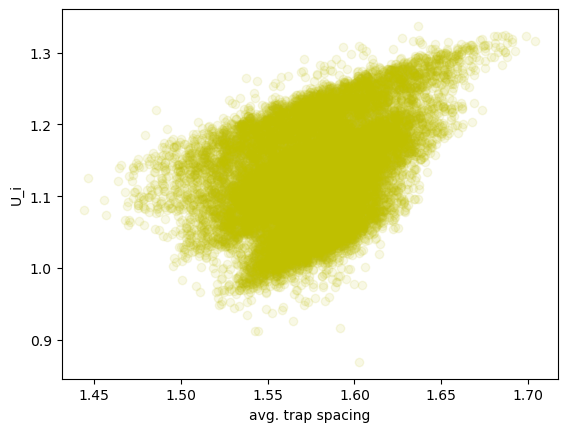

In [81]:
sidx = list(range(16))
plt.scatter(avgr.T, dat["U_i"][mask][:, sidx].flatten(), color="y", alpha=0.1)
plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")

Average trap spacing is a linear factor.

What about total spacing?

In [4]:
from typing import Iterable


def tot_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([tot_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    totr = np.sum(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return totr


totr = tot_trap_spacing(np.arange(16))

In [5]:
totr

array([[3.16460736, 3.10343096, 3.06765948, ..., 3.13977726, 3.14942692,
        2.95086692],
       [4.72186224, 4.72805327, 4.93259811, ..., 4.73479212, 4.81038679,
        4.7837442 ],
       [4.85550793, 4.78154609, 4.6878095 , ..., 4.70039186, 4.83534607,
        4.78871523],
       ...,
       [4.75493998, 4.75116136, 4.68967963, ..., 4.7866965 , 4.68228379,
        4.64911437],
       [4.6653241 , 4.72843657, 4.82287633, ..., 4.78804905, 4.73150567,
        4.84661637],
       [3.1721539 , 3.25340505, 3.2076577 , ..., 3.12583736, 3.26204102,
        3.28598815]])

Text(0, 0.5, 'U_i')

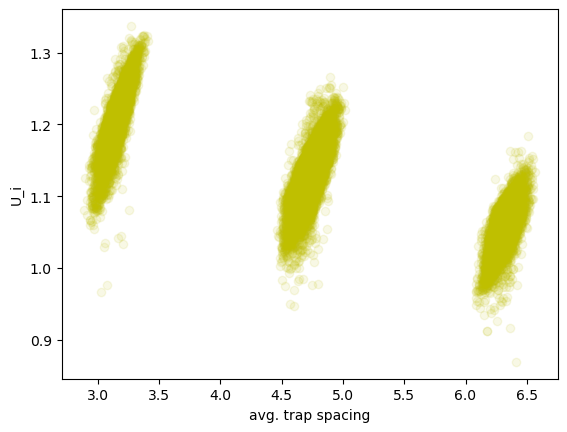

In [6]:
sidx = list(range(16))
plt.scatter(totr.T, dat["U_i"][mask][:, sidx].flatten(), color="y", alpha=0.1)
plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")

## Fittings

### Single factor V_offset

In [26]:
i = slice(16)
X = dat["V_offset"][mask, i].flatten()
arg = np.argsort(X)
X = X[arg]
Y = dat["U_i"][mask, i].flatten()
Y = Y[arg]

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class LinearModel(nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        return self.a * x ** (3 / 4) + self.b


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = torch.tensor(X, dtype=torch.float32)
Y_torch = torch.tensor(Y, dtype=torch.float32)

# Initialize the model
model = LinearModel()

# Loss Function and Optimizer
criterion = nn.MSELoss()
# optimizer = optim.SGD(model.parameters(), lr=0.01)
# Using L-BFGS Optimizer
maxiter = 1000
tol = 1e-9
optimizer = optim.LBFGS(
    model.parameters(),
    lr=0.005,
    max_iter=maxiter,
    tolerance_grad=tol * 1e2,
    tolerance_change=tol,
)

# Training Loop
loss_old = torch.inf
loss_new = torch.inf


def closure():
    optimizer.zero_grad()
    outputs = model(X_torch)
    loss = criterion(outputs, Y_torch)
    loss.backward()
    return loss


# Training Loop
for epoch in range(maxiter):  # Number of epochs
    if loss_old - loss_new < tol:
        break
    loss_old = loss_new

    optimizer.step(closure)
    loss = closure().item()
    loss_new = loss
    # # Forward pass
    # outputs = model(X_torch)
    # loss = criterion(outputs, Y_torch)
    # loss_new = loss.item()
    if epoch % 1 == 0:
        print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
    # # Backward and optimize
    # optimizer.zero_grad()
    # loss.backward()
    # optimizer.step()


def r_squared(X, Y, model):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


r2 = r_squared(X_torch, Y_torch, model)
a = model.a.item()
b = model.b.item()

print(f"Exponential model: Y = {b} + {a} * X")
print(f"Final Loss: {loss_new:.4f}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.0044
Epoch [2/1000], Loss: 0.0035
Epoch [3/1000], Loss: 0.0035
Epoch [4/1000], Loss: 0.0035
Epoch [5/1000], Loss: 0.0035
Epoch [6/1000], Loss: 0.0035
Epoch [7/1000], Loss: 0.0035
Epoch [8/1000], Loss: 0.0035
Epoch [9/1000], Loss: 0.0035
Epoch [10/1000], Loss: 0.0035
Epoch [11/1000], Loss: 0.0035
Epoch [12/1000], Loss: 0.0035
Epoch [13/1000], Loss: 0.0035
Epoch [14/1000], Loss: 0.0035
Exponential model: Y = -2.1243338584899902 + 3.2524969577789307 * X
Final Loss: 0.0035
R^2 Score: 0.21541434526443481


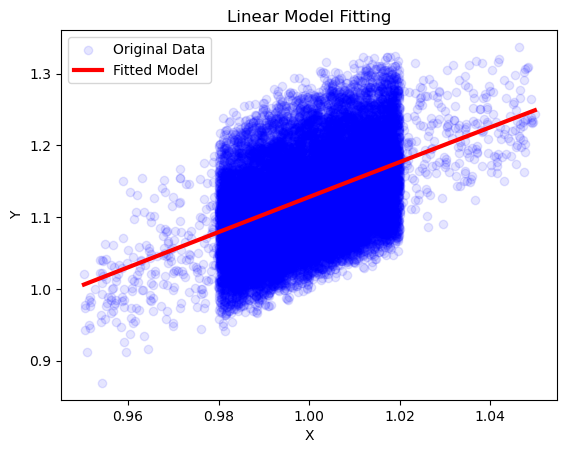

In [36]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
plt.scatter(X_torch, Y_torch, color="blue", label="Original Data", alpha=0.1)

# Plotting the model's predictions
plt.plot(X_torch, predicted, color="red", label="Fitted Model", linewidth=3)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Model Fitting")
plt.legend()

The 3/4 scaling is not easy to tell from linear in this narrow range of X.

### Inclusde neighbor number

In [ ]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


nn = nneighbor(width, height)

In [ ]:
i = slice(16)
X = dat["V_offset"][mask, i]
arg = np.argsort(X)
X = X[arg]
Y = dat["U_i"][mask, i]
Y = Y[arg]